In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Khai báo đường dẫn để gọi được file load_data.py
sys.path.append('../../')
from src.utils.load_data import load_heart_data

# Đọc dữ liệu
df = load_heart_data('../../data/raw/heart.csv')

✅ Đọc dữ liệu thành công!
📊 Kích thước: 297 dòng (bệnh nhân) x 14 cột (thuộc tính).


In [2]:
"""
    Xem xét cấu trúc và dữ liệu thiếu
    """
display(df.head())
print("\n--- THÔNG TIN CẤU TRÚC ---")
df.info()

print("\n--- KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ---")
print(df.isnull().sum())
# Dữ liệu heart.csv chuẩn thường không có missing values, rất sạch!

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0



--- THÔNG TIN CẤU TRÚC ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB

--- KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ---
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang 

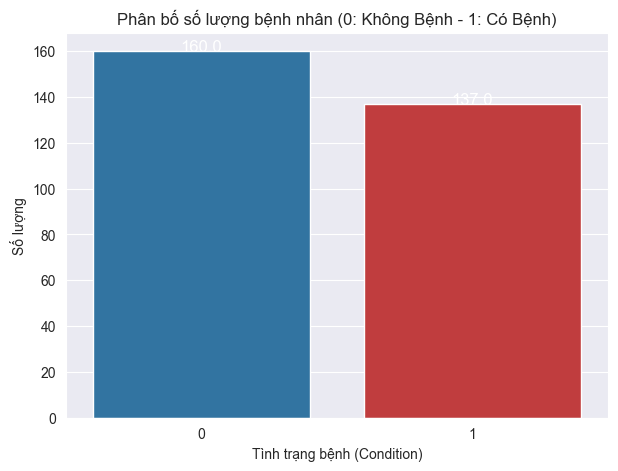

condition
0    53.872054
1    46.127946
Name: proportion, dtype: float64


In [5]:
"""
    Phân tích phân bố lớp (Target)
    """
plt.figure(figsize=(7, 5))
# Sửa 'target' thành 'condition' ở dòng này
ax = sns.countplot(data=df, x='condition', hue='condition', palette=['#1f77b4', '#d62728'], legend=False)
plt.title('Phân bố số lượng bệnh nhân (0: Không Bệnh - 1: Có Bệnh)')
plt.xlabel('Tình trạng bệnh (Condition)')
plt.ylabel('Số lượng')

# Hiển thị số lượng cụ thể trên cột
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.4, p.get_height()), ha='center', color='white', size=12)

plt.show()

# Sửa 'target' thành 'condition' ở dòng này luôn nhé
print(df['condition'].value_counts(normalize=True) * 100)

age: Tuổi của bệnh nhân.

sex: Giới tính (1 = Nam; 0 = Nữ).

cp: Loại đau ngực (0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic).

trestbps: Huyết áp lúc nghỉ ngơi (mm Hg).

chol: Lượng Cholesterol trong máu (mg/dl).

fbs: Lượng đường trong máu lúc đói (> 120 mg/dl: 1 = True; 0 = False).

restecg: Kết quả điện tâm đồ lúc nghỉ (0, 1, 2).

thalach: Nhịp tim tối đa đạt được.

exang: Đau thắt ngực do tập thể dục (1 = Có; 0 = Không).

oldpeak: Độ suy giảm ST do tập thể dục so với lúc nghỉ.

slope: Độ dốc của đoạn ST khi tập thể dục cường độ cao (0, 1, 2).

ca: Số lượng mạch máu chính (0-3) được tô màu bằng fluoroscopy.

thal: Tình trạng máu (Thalassemia) (1 = Bình thường; 2 = Khiếm khuyết cố định; 3 = Khiếm khuyết có thể phục hồi).

condition: Biến mục tiêu chẩn đoán (1 = Mắc bệnh tim; 0 = Không mắc bệnh).